<a href="https://colab.research.google.com/github/azrapatvi/dl-practice/blob/main/18_Medical_Insurance_Charges_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [31]:
import os

df=pd.read_csv(os.path.join(path,"insurance.csv"))
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [32]:
df.shape

(1338, 7)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [34]:
df.duplicated().sum()

np.int64(1)

In [35]:
df.drop_duplicates(inplace=True)

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [38]:
num_cols=[i for i in df.columns if df[i].dtypes!='O']
num_cols

['age', 'bmi', 'children', 'charges']

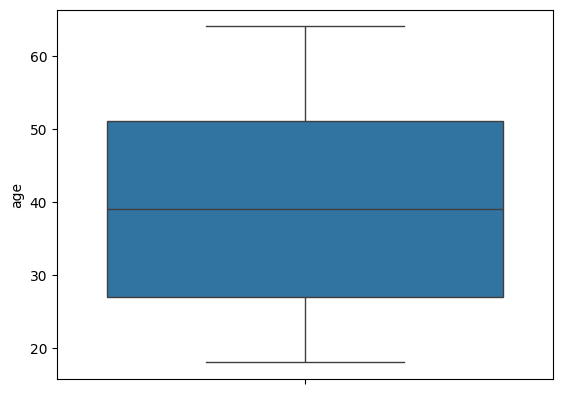

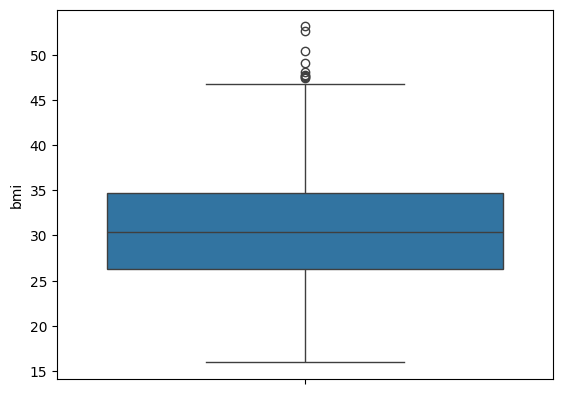

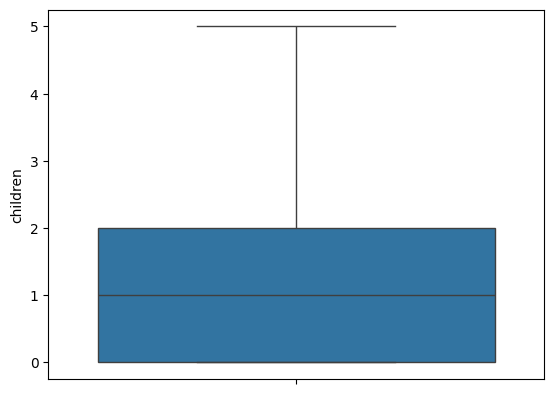

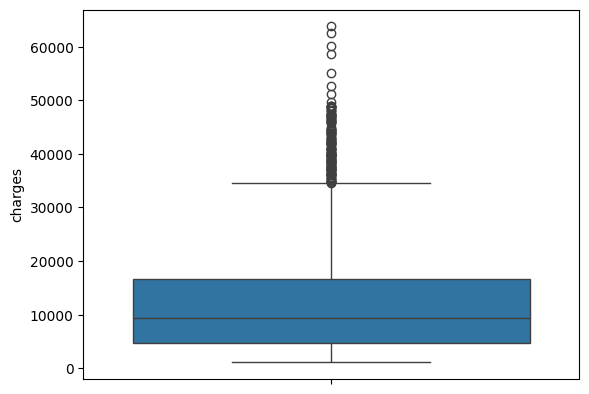

In [39]:
for i in num_cols:
  sns.boxplot(df[i])
  plt.show()

In [40]:
df["bmi"].skew()

np.float64(0.28391419385321137)

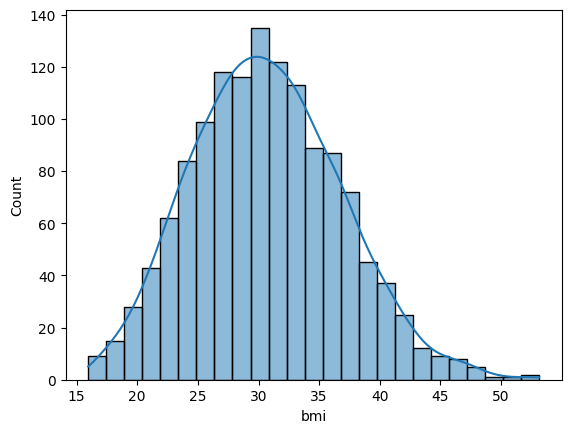

In [41]:
sns.histplot(df["bmi"], kde=True)
plt.show()

In [42]:
df['charges'].skew()

np.float64(1.5153909108403483)

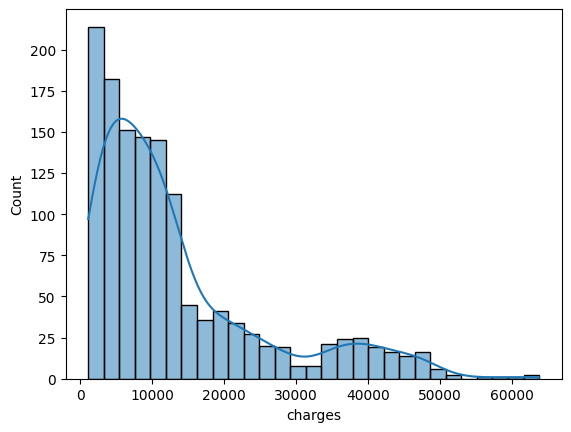

In [43]:
sns.histplot(df["charges"], kde=True)
plt.show()

In [44]:
cat_cols=[i for i in df.columns if df[i].dtypes=='O']
cat_cols

['sex', 'smoker', 'region']

In [45]:
for i in cat_cols:
  print(df[i].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


In [46]:
df['sex']=df['sex'].map({'female':1,'male':0})
df['smoker']=df['smoker'].map({'yes':1,'no':0})

In [47]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#bmi ->standardscler
#region ->ohe
# other->paasthorugh

ohe_col=['region']
scaler_col=['bmi']
pass_col=['age','sex','children','smoker']

ohe_pipeline=Pipeline([
    ("ohe",OneHotEncoder(handle_unknown='ignore'))
])

scaler_pipeline=Pipeline([
    ("scaler",StandardScaler())
])

preprocessor=ColumnTransformer([
    ("ohe_pipeline",ohe_pipeline,ohe_col),
    ("scaler_pipeline",scaler_pipeline,scaler_col),
    ("pass_col","passthrough",pass_col)
])

In [48]:
preprocessor

ColumnTransformer(transformers=[('ohe_pipeline',
                                 Pipeline(steps=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['region']),
                                ('scaler_pipeline',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['bmi']),
                                ('pass_col', 'passthrough',
                                 ['age', 'sex', 'children', 'smoker'])])

In [49]:
X=df.drop('charges',axis=1)
y=df['charges']

In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
X_train_preprocessed=preprocessor.fit_transform(X_train)
X_test_preprocessed=preprocessor.transform(X_test)

In [53]:
X_train_preprocessed.shape

(1069, 9)

In [54]:
#ann model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout

model=Sequential()
model.add(Dense(128,activation='relu',input_dim=X_train_preprocessed.shape[1]))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='linear'))

model.compile(optimizer='adam',loss='mse',metrics=['mae'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history=model.fit(X_train_preprocessed,y_train,epochs=200,validation_data=(X_test_preprocessed,y_test),callbacks=[early_stopping])

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 85072040.0000 - mae: 7235.3262 - val_loss: 108540456.0000 - val_mae: 7807.6821
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 82451432.0000 - mae: 6923.4771 - val_loss: 105875624.0000 - val_mae: 7545.2603
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 79386856.0000 - mae: 6800.0059 - val_loss: 100400992.0000 - val_mae: 7586.7998
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 76853664.0000 - mae: 6698.9912 - val_loss: 95929608.0000 - val_mae: 7446.8086
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 73325672.0000 - mae: 6567.5757 - val_loss: 93036544.0000 - val_mae: 7008.1040
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 69993072.0000 - mae: 6274.3667 - val_loss: 88158664.0000 - val_mae: 6797.2524
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 66552544.0000 - mae: 5886.5210 - val_loss: 81550160.0000 - val_mae: 6928.9429
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━

In [59]:
new_data = pd.DataFrame({
    "age": [30],
    "sex": [1],
    "bmi": [26.50],
    "children": [2],
    "smoker": [0],
    "region": ["southeast"]
})

In [60]:
new_data_processed=preprocessor.transform(new_data)

In [61]:
new_data_processed

array([[ 0.        ,  0.        ,  1.        ,  0.        , -0.66794823,
        30.        ,  1.        ,  2.        ,  0.        ]])

In [62]:
prediction=model.predict(new_data_processed)

print("Predicted medical insurance charge:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
Predicted medical insurance charge: [[6409.1343]]


In [58]:
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.90,0,1,southwest,16884.9240
1,18,0,33.77,1,0,southeast,1725.5523
